In [4]:
pip install rasterio

   ---------------------------------------- 0.0/30.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/30.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.7 MB 2.7 MB/s eta 0:00:12
   - -------------------------------------- 1.3/30.7 MB 2.5 MB/s eta 0:00:12
   -- ------------------------------------- 1.6/30.7 MB 2.6 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/30.7 MB 2.3 MB/s eta 0:00:13
   --- ------------------------------------ 2.6/30.7 MB 2.4 MB/s eta 0:00:12
   --- ------------------------------------ 2.9/30.7 MB 2.1 MB/s eta 0:00:14
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ----- ---------------------------------- 3.9/30.7 MB 1.8 MB/s eta 0:00:15
   ----- -----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import openeo
import pandas as pd

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================
# Sesuaikan nama file zip non-sawah milikmu di baris kedua
gdf_sawah = gpd.read_file("Sawah-baron.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("nonsawah-baron.zip").to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")

Jumlah sampel Sawah     : 51
Jumlah sampel Non-Sawah : 51
Total sampel gabungan   : 102
Bounding Box Gabungan: {'west': 112.0286883, 'south': -7.5874895, 'east': 112.0537555, 'north': -7.5647792}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif


In [5]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

# ==============================================================================
# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
# ==============================================================================
fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'


C:\Users\Asus\AppData\Local\Temp\ipykernel_7104\276632000.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
C:\Users\Asus\AppData\Local\Temp\ipykernel_7104\276632000.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,517,663,470,2654,1631,0.699104,-0.600241,112.034155,-7.576800,Sawah,1
1,514,685,507,2969,1806,0.708285,-0.625068,112.037241,-7.576929,Sawah,1
2,520,669,452,3169,1601,0.750345,-0.651381,112.035995,-7.577839,Sawah,1
3,546,747,458,2864,1698,0.724262,-0.586264,112.039530,-7.574546,Sawah,1
4,705,949,813,2847,1861,0.555738,-0.500000,112.036919,-7.574629,Sawah,1



=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 95.24%

Confusion Matrix:
 [[10  1]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      0.91      0.95        11
       Sawah       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



In [8]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

# 1. Muat dataset dari CSV
df_dataset = pd.read_csv("dataset_100sampel_sawah_nonsawah.csv")

# 2. Siapkan fitur dan target
fitur_kolom = [c for c in ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"] if c in df_dataset.columns]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# 3. Split 80% Training & 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi Testing : 95.24%

Confusion Matrix:
 [[10  1]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      0.91      0.95        11
       Sawah       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



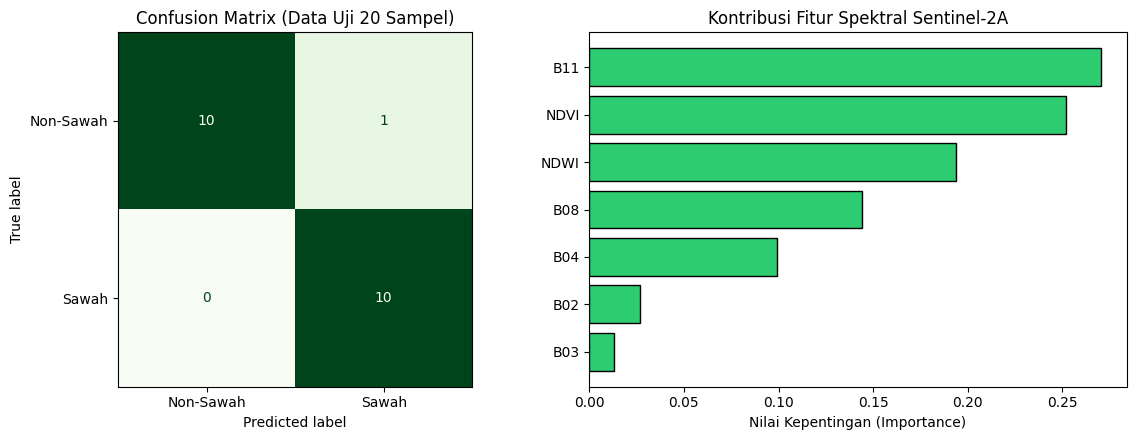

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


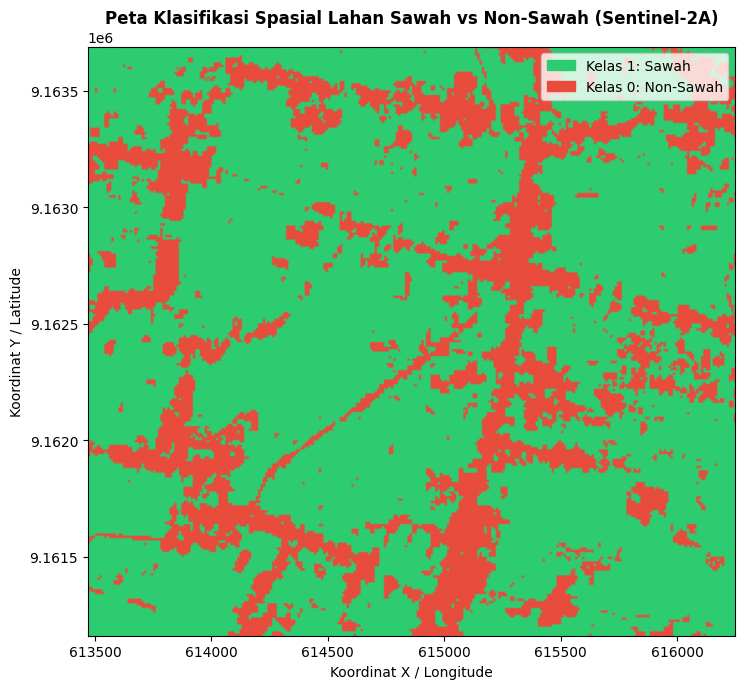

In [16]:
# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.show()

with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  img = src.read()  # Shape: (5 bands, height, width)
  profil_raster = src.profile
  bounds = src.bounds

# Ambil masing-masing band (B02, B03, B04, B08, B11)
b02, b03, b04, b08, b11 = (
    img[0].astype(float),
    img[1].astype(float),
    img[2].astype(float),
    img[3].astype(float),
    img[4].astype(float),
)

# Hitung NDVI dan NDWI untuk seluruh piksel di citra .tif
ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

# Susun seluruh piksel menjadi matriks 2D (baris = piksel, kolom = 7 fitur)
stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh piksel menggunakan model Random Forest yang sudah dilatih
prediksi_label = model_rf.predict(piksel_2d)

# Ubah hasil prediksi ('Sawah' -> 1, 'Non-Sawah' -> 0) kembali ke ukuran gambar 2D (h, w)
peta_biner = np.where(prediksi_label == "Sawah", 1, 0).reshape(h, w)

# Tampilkan Peta Hasil Klasifikasi Spasial
plt.figure(figsize=(9, 7))
cmap_sawah = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])  # Merah & Hijau
plt.imshow(
    peta_biner,
    cmap=cmap_sawah,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

# Legenda Peta
patch_sawah = mpatches.Patch(color="#2ecc71", label="Kelas 1: Sawah")
patch_nonsawah = mpatches.Patch(color="#e74c3c", label="Kelas 0: Non-Sawah")
plt.legend(handles=[patch_sawah, patch_nonsawah], loc="upper right")
plt.title(
    "Peta Klasifikasi Spasial Lahan Sawah vs Non-Sawah (Sentinel-2A)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X / Longitude")
plt.ylabel("Koordinat Y / Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_sawah.png", dpi=300)
plt.show()

In [11]:
print(X_train.shape)

(81, 7)


In [21]:
print(X_train.value_counts())
print(y_train.value_counts())

B02   B03   B04   B08   B11   NDVI      NDWI     
480   635   530   2766  1728  0.678398  -0.626580    1
487   651   495   2971  1617  0.714368  -0.640530    1
498   691   482   3030  1816  0.725513  -0.628594    1
500   654   481   3076  1671  0.729547  -0.649330    1
501   691   493   3223  1826  0.734661  -0.646909    1
                                                    ..
1207  1360  1523  1901  2500  0.110397  -0.165900    1
1377  1606  1868  2578  3000  0.159694  -0.232314    1
1492  1824  2012  2947  2650  0.188546  -0.235380    1
1769  1888  2034  2472  3177  0.097204  -0.133945    1
2708  2935  2927  3118  3130  0.031596  -0.030233    1
Name: count, Length: 81, dtype: int64
Kelas
Sawah        41
Non-Sawah    40
Name: count, dtype: int64


In [22]:
import rasterio
import numpy as np
import pandas as pd

with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
    img = src.read()              # shape: (band, tinggi, lebar)
    transform = src.transform
    nama_band = ["B02", "B03", "B04", "B08", "B11"]

n_band, h, w = img.shape

# Koordinat pusat tiap piksel
rows, cols = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
xs, ys = rasterio.transform.xy(transform, rows.ravel(), cols.ravel())

df = pd.DataFrame({
    "x": xs,
    "y": ys,
    **{nama: img[i].ravel() for i, nama in enumerate(nama_band)},
})

print(df.head())
print(df.shape)   # (h * w, 2 + jumlah band)

          x          y  B02  B03  B04   B08   B11
0  613475.0  9163685.0  470  652  510  2957  1459
1  613485.0  9163685.0  494  669  495  2915  1359
2  613495.0  9163685.0  502  664  512  2581  1359
3  613505.0  9163685.0  486  662  559  2286  1306
4  613515.0  9163685.0  454  641  526  2382  1306
(70334, 7)


In [23]:
pip install folium


   ---------------------------------------- 0/3 [xyzservices]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import folium

# 1. Tentukan koordinat pusat peta (contoh: Jakarta)
center_location = [-6.2088, 106.8456]
m = folium.Map(location=center_location, zoom_start=12)

# 2. URL XYZ Tiles untuk Google Satellite & Hybrid
google_satellite_url = 'https://google.com{x}&y={y}&z={z}'
google_hybrid_url = 'https://google.com{x}&y={y}&z={z}'

# 3. Tambahkan layer ke peta folium
folium.TileLayer(
    tiles=google_satellite_url,
    attr='Google',
    name='Google Satellite (Pure)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles=google_hybrid_url,
    attr='Google',
    name='Google Hybrid (Satelit + Jalan)',
    overlay=False,
    control=True
).add_to(m)

# Tambahkan kontrol layer agar pengguna bisa memilih basemap
folium.LayerControl().add_to(m)

# 4. Simpan peta ke file HTML
m.save('peta_satelit.html')


In [25]:
import streamlit as st
import pandas as pd
import numpy as np

# Membuat judul aplikasi
st.title("Aplikasi Matematika Sederhana 🧮")

# Membuat input angka dari pengguna menggunakan slider
angka = st.slider("Pilih sebuah angka:", min_value=1, max_value=100, value=25)

# Melakukan perhitungan
kuadrat = angka ** 2

# Menampilkan hasil perhitungan dalam bentuk teks besar
st.metric(label=f"Hasil kuadrat dari {angka}", value=kuadrat)

# Membuat grafik sederhana berdasarkan angka yang dipilih
st.subheader("Grafik Pertumbuhan Nilai Kuadrat")
data = pd.DataFrame({
    'Angka': range(1, angka + 1),
    'Kuadrat': [x**2 for x in range(1, angka + 1)]
})
st.line_chart(data.set_index('Angka'))


2026-10-05 09:09:18.642 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:18.912 
  command:

    streamlit run c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-10-05 09:09:18.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:18.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:18.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:18.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:18.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-05 09:09:1

DeltaGenerator()